In [1]:
# Cell 1 — Setup
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import pyogrio
from IPython.display import Image as IPImage

from scripts.shared import db_utils

conn = db_utils.db_connect()
ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'
OUT.mkdir(parents=True, exist_ok=True)

WORLD = gpd.read_file(Path(pyogrio.__file__).parent / 'tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp')

months = np.arange(12)
theta1 = 2 * np.pi * months / 12   # annual harmonic
theta2 = 2 * np.pi * months / 6    # semi-annual harmonic

print("Setup complete.")

Setup complete.


# WO6a — Non-compensatory similarity:

Tests a non-compensatory (Chebyshev-style) matching instrument as an alternative to the existing\ncomposite-distance lenses (`climate.temp`, `climate.precip`), which WO5 Part A Check 3 showed let\nfavourable shape agreement buy tolerance on absolute level. A basin qualifies only if it is close\non *every* condition — no trading off between them. Full spec: `docs/cdop/pilot/wo6a_notebook.md`.\n\nFour parts, run in order — **Part B's answer determines what WO6b builds**:\n\n- **Part A** — prominence threshold for peak-counting modality, swept corpus-wide (not just the\n  4 probes WO5's detour used)\n- **Part B** — absolute bands vs percentile bands, the decision this notebook exists to make\n- **Part C** — variable budget: how many simultaneous conditions before the instrument returns\n  nothing\n- **Part D** — cheap, independent check: does `climate.precip` have the same compensation defect\n  WO5 found in `climate.temp`?\n\nExploratory only — no engine writes, no registry changes, no API, no UI change."


In [2]:
# Cell 3 — Probe definitions
# WO4's 7-probe set plus Yakutsk (high-latitude sparse-end check, needed for Part B) --
# deep continental Siberia, picked over a coastal Arctic point (Tromso hit a basin-coverage
# gap: fjord/island coastline too fragmented for ST_Within to land in any L06 polygon there).
PROBES = [
    ('Mombasa',      -4.0435,   39.6682),
    ('Augsburg',     48.3705,   10.8978),
    ('Tbilisi',      41.6938,   44.8015),
    ('Kaifeng',      34.7986,  114.3413),
    ('Timbuktu',     16.8167,   -2.9833),
    ('George Town',   5.4141,  100.3288),
    ('Santiago',    -33.4489,  -70.6693),
    ('Yakutsk',      62.0280,  129.7326),
]
probe_df = pd.DataFrame(PROBES, columns=['probe', 'lat', 'lon'])
print(probe_df.to_string(index=False))

      probe      lat      lon
    Mombasa  -4.0435  39.6682
   Augsburg  48.3705  10.8978
    Tbilisi  41.6938  44.8015
    Kaifeng  34.7986 114.3413
   Timbuktu  16.8167  -2.9833
George Town   5.4141 100.3288
   Santiago -33.4489 -70.6693
    Yakutsk  62.0280 129.7326


In [3]:
# Cell 4 — Resolve each probe's L06 basin; pull its monthly arrays + BasinATLAS scalars
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

def resolve_basin(level, lat, lon):
    table = 'basin06' if level == 6 else 'basin08'
    sql = f"""
    SELECT hybas_id FROM {table}
    WHERE ST_Within(ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326), geom)
    ORDER BY ST_Area(geom::geography) ASC LIMIT 1
    """
    row = pd.read_sql(sql, conn)
    return None if row.empty else int(row.iloc[0]['hybas_id'])

rows = []
for name, lat, lon in PROBES:
    hybas_id = resolve_basin(6, lat, lon)
    if hybas_id is None:
        print(f"  WARNING: no L06 basin found for {name}")
        continue
    arr = pd.read_sql(
        "SELECT pre_mm_monthly, tmp_dc_monthly FROM public.v_basin06_persist_rev2 WHERE hybas_id = %(h)s",
        conn, params={'h': hybas_id},
    )
    sc = pd.read_sql(
        "SELECT pre_mm_syr, tmp_dc_syr FROM public.basin06 WHERE hybas_id = %(h)s",
        conn, params={'h': hybas_id},
    )
    pre_monthly = np.array(arr.iloc[0]['pre_mm_monthly'], dtype=float)
    tmp_monthly = np.array(arr.iloc[0]['tmp_dc_monthly'], dtype=float)  # already deg C, not x10
    rows.append({
        'probe': name, 'lat': lat, 'lon': lon, 'hybas_id': hybas_id,
        'pre_mm_monthly': pre_monthly,
        'tmp_dc_monthly': tmp_monthly,
        'pre_mm_syr': float(sc.iloc[0]['pre_mm_syr']),
        'tmp_dc_syr': float(sc.iloc[0]['tmp_dc_syr']) / 10.0,
        'tmp_seas_amp': float(tmp_monthly.max() - tmp_monthly.min()),
    })

probes = pd.DataFrame(rows)
print(probes[['probe', 'hybas_id', 'pre_mm_syr', 'tmp_dc_syr', 'tmp_seas_amp']].to_string(index=False))

      probe   hybas_id  pre_mm_syr  tmp_dc_syr  tmp_seas_amp
    Mombasa 1060008650      1101.0        25.4           4.1
   Augsburg 2060461650      1006.0         6.2          17.7
    Tbilisi 2060616700       762.0         5.3          21.7
    Kaifeng 4060675920       710.0        14.8          27.7
   Timbuktu 1060551560       189.0        28.6          12.3
George Town 4060020990      2656.0        26.8           1.0
   Santiago 6060027290       495.0         9.7          11.4
    Yakutsk 3060350280       261.0       -10.2          59.6


In [4]:
# Cell 5 — Corpus load: monthly arrays + BasinATLAS scalars + representative points, L06 and L08
# One query pair per level, shared by Parts A-C below. Basin representative point is
# ST_PointOnSurface, not ST_Centroid (WO5/context.py convention -- a plain centroid can
# fall outside a concave basin polygon).
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

corpus = {}
for level, view, table in ((6, 'v_basin06_persist_rev2', 'basin06'), (8, 'v_basin08_persist_rev2', 'basin08')):
    arr = pd.read_sql(
        f"SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly, zone_name, biome FROM public.{view}", conn)
    sc = pd.read_sql(
        f"SELECT hybas_id, pre_mm_syr, tmp_dc_syr, "
        f"ST_Y(ST_PointOnSurface(geom)) AS lat, ST_X(ST_PointOnSurface(geom)) AS lon "
        f"FROM public.{table}", conn)
    arr['hybas_id'] = arr['hybas_id'].astype(np.int64)
    sc['hybas_id']  = sc['hybas_id'].astype(np.int64)
    df = arr.merge(sc, on='hybas_id', how='left')

    PRE = np.array(df['pre_mm_monthly'].tolist(), dtype=float)
    TMP = np.array(df['tmp_dc_monthly'].tolist(), dtype=float)  # already deg C, per seasonality.py

    # NoData mask + scale, mirroring app/db/context.py's exact pattern (check sentinel
    # against -9999*scale on the raw column, then scale).
    for col, scale in (('pre_mm_syr', 1.0), ('tmp_dc_syr', 0.1)):
        df[col] = df[col].astype(float)
        df.loc[df[col] == -9999 * scale, col] = np.nan
        df[col] = df[col] * scale

    df['tmp_seas_amp'] = TMP.max(axis=1) - TMP.min(axis=1)

    valid = (~np.isnan(PRE).any(axis=1) & (PRE.sum(axis=1) > 0)
             & df['pre_mm_syr'].notna() & df['tmp_dc_syr'].notna())
    valid_np = valid.to_numpy()
    df = df[valid].reset_index(drop=True)
    corpus[level] = {'df': df, 'PRE': PRE[valid_np], 'TMP': TMP[valid_np]}
    print(f"L{level}: {len(df)} valid basins ({valid_np.sum()}/{len(valid_np)})")

L8: 189956 valid basins (189956/190675)


## Part A — Prominence threshold for peak-counting modality

WO5's detour (`scripts/cdop/wo5_modality_peak_count_probe.py`) found prominence-filtered\npeak-counting correct on all 4 probes checked, including both of `R_dbl`'s known failure\ndirections (Timbuktu false-positive, George Town false-negative). That script swept prominence\nfractions 10/20/30/40% by hand on 4 basins. Here the same algorithm runs corpus-wide (all L06\nbasins, and L08 since the vectorized form costs nothing extra) across a finer sweep, looking for\na stability plateau — a real feature of the data, not a number picked by eye on 4 cases."


In [8]:
# Cell 7 — Vectorized circular peak-counting (prominence-filtered), corpus-scale
# Reimplements scripts/cdop/wo5_modality_peak_count_probe.py's circular_peaks() logic,
# batched over all basins at once via 12 fixed index-arithmetic steps per direction (not
# a Python loop over basins) -- validated below against that script's own scalar version.

def _walk_to_col(V, s, step):
    """Vectorized: for every row, the lowest value reached walking from position s in
    `step` direction before the curve exceeds V[:, s] again (or a full loop)."""
    N = V.shape[0]
    floor  = np.full(N, np.inf)
    active = np.ones(N, dtype=bool)
    vs = V[:, s]
    i = s
    for _ in range(12):
        i = (i + step) % 12
        cur = V[:, i]
        active &= ~(cur > vs)
        if not active.any():
            break
        floor = np.where(active, np.minimum(floor, cur), floor)
    return floor

def circular_peak_count(V, frac, abs_floor_mm=0.0):
    """V: (N,12) monthly array. frac: prominence threshold as a fraction of each
    basin's own annual range. abs_floor_mm: additional absolute floor (mm) -- a peak
    must clear max(frac*range, abs_floor_mm), so noise in a near-flat arid/cold basin
    (tiny range, so a small absolute wobble can be a "large" fraction of it) can't
    register as a real second season. Default 0.0 reproduces the relative-only WO5
    behaviour exactly, for the validation below. Returns (N,) int array of peak counts."""
    rng = V.max(axis=1) - V.min(axis=1)
    thresh = np.maximum(frac * rng, abs_floor_mm)
    count = np.zeros(V.shape[0], dtype=int)
    for s in range(12):
        left, right = V[:, (s - 1) % 12], V[:, (s + 1) % 12]
        vs = V[:, s]
        is_candidate = (vs >= left) & (vs >= right) & ((vs > left) | (vs > right))
        prominence = vs - np.maximum(_walk_to_col(V, s, -1), _walk_to_col(V, s, +1))
        count += (is_candidate & (prominence >= thresh)).astype(int)
    return count

def _circular_peaks_reference(values, min_prominence):
    """Direct, unvectorized port of the WO5 script's circular_peaks() -- one basin at a
    time -- used only to validate the vectorized version above, never run at corpus scale."""
    n = len(values)
    v = np.asarray(values, dtype=float)
    candidates = []
    for i in range(n):
        left, right = v[(i - 1) % n], v[(i + 1) % n]
        if v[i] >= left and v[i] >= right and (v[i] > left or v[i] > right):
            candidates.append(i)

    def walk_to_col(start, step):
        floor = np.inf
        i = (start + step) % n
        for _ in range(n):
            if v[i] > v[start]:
                break
            floor = min(floor, v[i])
            i = (i + step) % n
        return floor

    peaks = 0
    for i in candidates:
        prominence = v[i] - max(walk_to_col(i, -1), walk_to_col(i, +1))
        if prominence >= min_prominence:
            peaks += 1
    return peaks

# Validation: vectorized vs scalar reference, on the 4 probes the WO5 script checked
# (abs_floor_mm left at its default 0.0 here -- this validates against WO5's own
# relative-only script, not the floored version used corpus-wide from Cell 8 on)
val_probes = probes[probes['probe'].isin(['Mombasa', 'Timbuktu', 'George Town', 'Augsburg'])]
print("Cross-checking vectorized circular_peak_count against the scalar reference:")
all_pass = True
for _, prow in val_probes.iterrows():
    monthly = prow['pre_mm_monthly']
    rng = monthly.max() - monthly.min()
    for frac in (0.10, 0.20, 0.30, 0.40):
        ref = _circular_peaks_reference(monthly, frac * rng)
        vec = int(circular_peak_count(monthly[None, :], frac)[0])
        ok = ref == vec
        all_pass &= ok
        print(f"  {prow['probe']:12s} frac={frac:.0%}  reference={ref}  vectorized={vec}  {'OK' if ok else 'MISMATCH'}")
print("ALL PASS" if all_pass else "MISMATCH FOUND -- do not trust the corpus-wide sweep below until fixed")
print("\nExpected per wo5_findings.md: Timbuktu=1 always; Mombasa 2@10%->1@20%+; "
      "George Town=2 always; Augsburg=1 always.")

Cross-checking vectorized circular_peak_count against the scalar reference:
  Mombasa      frac=10%  reference=2  vectorized=2  OK
  Mombasa      frac=20%  reference=1  vectorized=1  OK
  Mombasa      frac=30%  reference=1  vectorized=1  OK
  Mombasa      frac=40%  reference=1  vectorized=1  OK
  Augsburg     frac=10%  reference=1  vectorized=1  OK
  Augsburg     frac=20%  reference=1  vectorized=1  OK
  Augsburg     frac=30%  reference=1  vectorized=1  OK
  Augsburg     frac=40%  reference=1  vectorized=1  OK
  Timbuktu     frac=10%  reference=1  vectorized=1  OK
  Timbuktu     frac=20%  reference=1  vectorized=1  OK
  Timbuktu     frac=30%  reference=1  vectorized=1  OK
  Timbuktu     frac=40%  reference=1  vectorized=1  OK
  George Town  frac=10%  reference=2  vectorized=2  OK
  George Town  frac=20%  reference=2  vectorized=2  OK
  George Town  frac=30%  reference=2  vectorized=2  OK
  George Town  frac=40%  reference=2  vectorized=2  OK
ALL PASS

Expected per wo5_findings.md: Timb

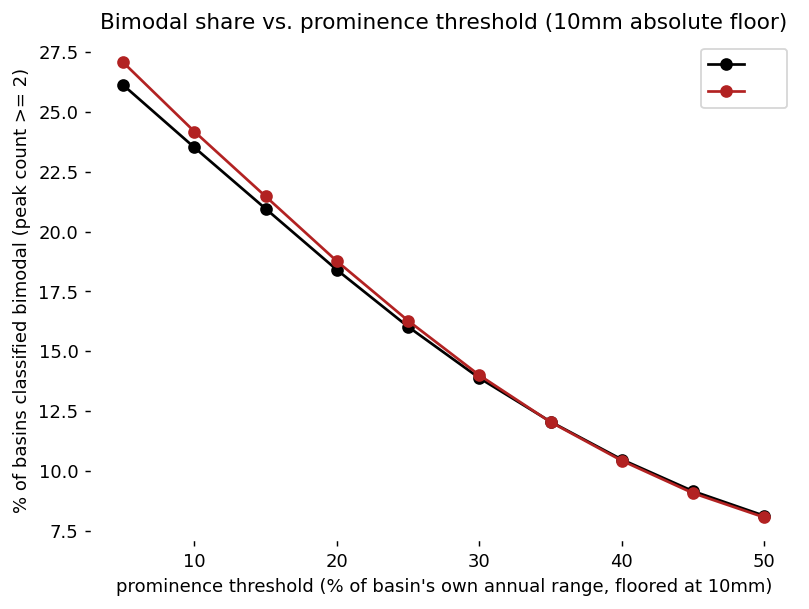

In [15]:
# Cell 8 — Corpus-wide prominence sweep, both levels
# ABS_FLOOR_MM: Cell 9's first pass (no floor) showed the "bimodal" class dominated by
# cold/arid/xeric zones at the strict end -- backwards from the expected ITCZ/monsoon/Sahel
# geography, and consistent with noise in a near-flat, low-precip curve trivially exceeding
# a purely relative (fraction-of-own-range) threshold. 20mm fixed that but, per Cell 12's
# pinned Somalia check, also suppressed a real secondary peak (~13mm prominence, the Deyr
# rains) in a textbook two-monsoon climate. Lowered to 10mm here to let that real signal
# through; re-check both the arid-noise geography (Cell 9/10) and Somalia (Cell 12) again
# at this new value before trusting either.
ABS_FLOOR_MM = 10.0
FRACTIONS = np.round(np.arange(0.05, 0.51, 0.05), 2)

sweep_rows = []
for level, data in corpus.items():
    V = data['PRE']
    for frac in FRACTIONS:
        counts = circular_peak_count(V, frac, abs_floor_mm=ABS_FLOOR_MM)
        bimodal = counts >= 2
        sweep_rows.append({
            'level': level, 'frac': frac,
            'n_bimodal': int(bimodal.sum()), 'pct_bimodal': 100 * bimodal.mean(),
        })

sweep = pd.DataFrame(sweep_rows)
print(sweep.to_string(index=False))

print("drawing prominence sweep...")
fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
for level, grp in sweep.groupby('level'):
    color = 'black' if level == 6 else 'firebrick'
    ax.plot(grp['frac'] * 100, grp['pct_bimodal'], marker='o', label=f'L{level}', color=color)
ax.set_xlabel("prominence threshold (% of basin's own annual range, floored at 10mm)", color='black')
ax.set_ylabel('% of basins classified bimodal (peak count >= 2)', color='black')
ax.set_title('Bimodal share vs. prominence threshold (10mm absolute floor)', color='black')
ax.tick_params(colors='black')
ax.legend()
out_path = OUT / 'wo6a_prominence_sweep.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

In [16]:
# Cell 9 — Geography of the bimodal class at a recommended threshold + sweep endpoints
# RECOMMENDED_FRAC is provisional -- 0.20 matches the midpoint of WO5's own 4-probe sweep,
# where Mombasa's flip landed. Inspect the sweep table/plot above for a flat stretch first;
# if a real plateau shows up somewhere else, move this to its midpoint before reading on.
RECOMMENDED_FRAC = 0.20
CHECK_FRACS = sorted({float(FRACTIONS.min()), RECOMMENDED_FRAC, float(FRACTIONS.max())})

for level, data in corpus.items():
    df, V = data['df'], data['PRE']
    print(f"\n=== L{level} ===")
    for frac in CHECK_FRACS:
        bimodal = circular_peak_count(V, frac, abs_floor_mm=ABS_FLOOR_MM) >= 2
        print(f"\n  frac={frac:.0%}: {bimodal.sum()} bimodal / {len(df)} ({100 * bimodal.mean():.1f}%)")
        print("  by zone_name (top 10):")
        print(df.loc[bimodal, 'zone_name'].value_counts().head(10).to_string())


  frac=20%: 35638 bimodal / 189956 (18.8%)
  by zone_name (top 10):
zone_name
Extremely hot and moist     6854
Hot and dry                 3745
Warm temperate and mesic    3731
Hot and mesic               2986
Extremely hot and xeric     2836
Cool temperate and xeric    2223
Cold and mesic              2209
Extremely cold and mesic    2155
Cool temperate and dry      2116
Warm temperate and xeric    1661

  frac=50%: 15314 bimodal / 189956 (8.1%)
  by zone_name (top 10):
zone_name
Extremely hot and moist     1752
Extremely hot and xeric     1726
Hot and dry                 1568
Warm temperate and mesic    1437
Cool temperate and xeric    1390
Extremely cold and mesic    1297
Cold and mesic              1107
Cool temperate and dry      1058
Hot and mesic                962
Warm temperate and xeric     883


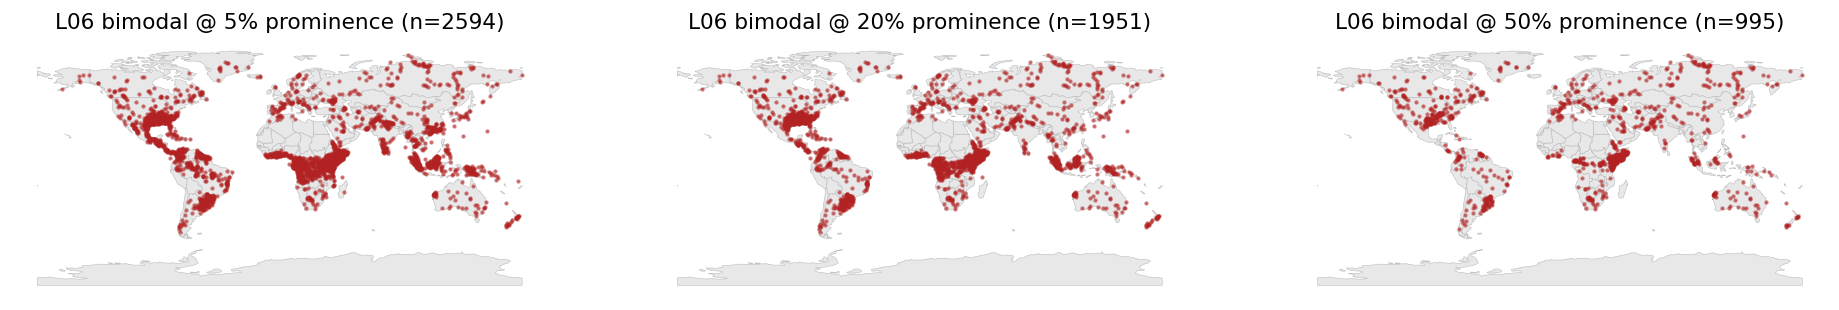

In [11]:
# Cell 10 — Map: bimodal-class basins at the sweep endpoints and RECOMMENDED_FRAC, L06
# The equatorial double-ITCZ belt, monsoon Asia, and the Sahel margin should appear --
# if they don't, the measure is wrong regardless of what the count curve looked like.
print("drawing bimodal geography map...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')
df6, V6 = corpus[6]['df'], corpus[6]['PRE']
for ax, frac in zip(axes, CHECK_FRACS):
    ax.set_facecolor('white')
    WORLD.plot(ax=ax, color='#e8e8e8', edgecolor='#bbbbbb', linewidth=0.3)
    bimodal = circular_peak_count(V6, frac, abs_floor_mm=ABS_FLOOR_MM) >= 2
    ax.scatter(df6.loc[bimodal, 'lon'], df6.loc[bimodal, 'lat'], s=2, color='firebrick', alpha=0.5)
    ax.set_title(f'L06 bimodal @ {frac:.0%} prominence (n={bimodal.sum()})', color='black')
    ax.set_xticks([]); ax.set_yticks([])
out_path = OUT / 'wo6a_bimodal_geography.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

In [12]:
# Cell 11 — R_dbl vs peak-count classification, L06, at RECOMMENDED_FRAC (with floor)
# R_dbl = sqrt(a2^2+b2^2), the retired climate.phase-era bimodality measure (WO2/WO2a);
# THRESH_DBL = 0.30 was the WO2a held-out threshold.
V6 = corpus[6]['PRE']
total = V6.sum(axis=1)
a2 = (V6 * np.cos(theta2)).sum(axis=1) / total
b2 = (V6 * np.sin(theta2)).sum(axis=1) / total
r_dbl = np.sqrt(a2**2 + b2**2)
THRESH_DBL = 0.30

peak_count_l06 = circular_peak_count(V6, RECOMMENDED_FRAC, abs_floor_mm=ABS_FLOOR_MM)
peak_bimodal = peak_count_l06 >= 2
rdbl_bimodal = r_dbl > THRESH_DBL

confusion = pd.crosstab(
    pd.Series(peak_bimodal, name='peak_count>=2'),
    pd.Series(rdbl_bimodal, name='R_dbl>0.30'),
)
print(confusion)
print(f"\nAgreement: {(peak_bimodal == rdbl_bimodal).mean():.1%} of {len(peak_bimodal)} L06 basins")

df6 = corpus[6]['df']
disagree_mask = peak_bimodal != rdbl_bimodal
disagree = df6.loc[disagree_mask].copy()
disagree['r_dbl'] = r_dbl[disagree_mask]
disagree['peak_count'] = peak_count_l06[disagree_mask]
print(f"\n{len(disagree)} disagreeing basins ({100 * len(disagree) / len(df6):.1f}%)")
print(disagree[['hybas_id', 'zone_name', 'r_dbl', 'peak_count', 'lat', 'lon']]
      .sample(min(10, len(disagree)), random_state=0).to_string(index=False))

R_dbl>0.30     False  True 
peak_count>=2              
False          11749   2638
True            1636    315

Agreement: 73.8% of 16338 L06 basins

4274 disagreeing basins (26.2%)
  hybas_id                zone_name    r_dbl  peak_count        lat        lon
4060548960 Extremely cold and mesic 0.106593           2  37.295833  73.314583
4061081310  Extremely hot and xeric 0.350268           1  18.042879  80.608633
1061434080  Extremely hot and moist 0.398389           1 -15.606306  30.979117
4061013640  Extremely hot and moist 0.519714           1  22.642538  82.550611
1060006860  Extremely hot and xeric 0.669929           1   9.894044  50.490052
1061213630  Extremely hot and moist 0.271165           2  -3.216836  15.852356
1061001800  Extremely hot and xeric 0.115036           2   5.175587  34.388727
7060610850 Warm temperate and mesic 0.030894           2  36.412500 -88.073915
2060085520  Extremely hot and xeric 0.383178           0  21.058157  52.450470
5060059950  Extremely hot a

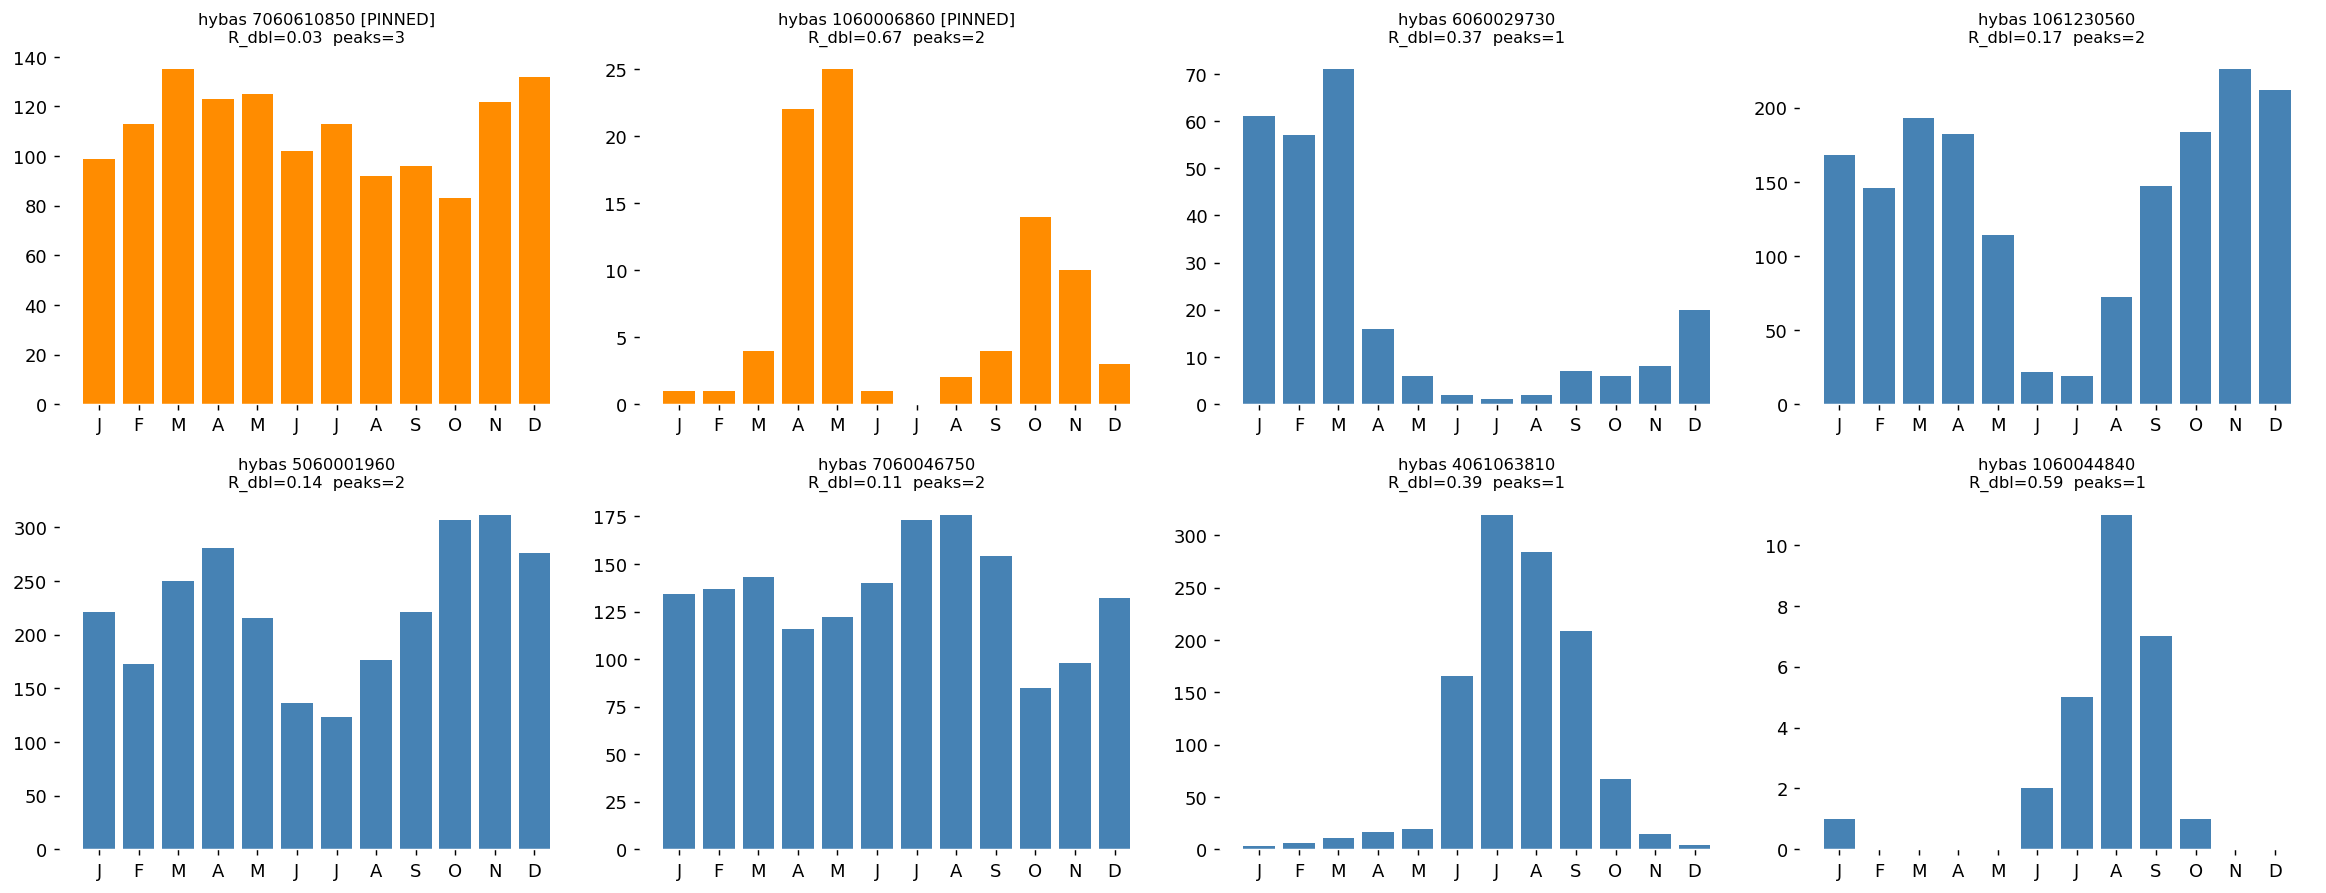

In [17]:
# Cell 12 — Monthly profiles for a sample of disagreeing basins
# "Draw the compared dimension before theorising about the measure" -- this rule paid off
# three times already per the WO text (WO2a validation, George Town, the peak-count detour).
# Two named basins pinned first, not left to chance in the random draw: hybas 1060006860
# (Horn of Africa, lat 9.89/lon 50.49) -- a textbook bimodal region (Gu/Deyr monsoon rains)
# that R_dbl calls strongly bimodal (0.67) but peak-count calls unimodal, worth checking
# whether the two wet seasons are too close together to leave a deep enough valley; and
# hybas 7060610850 (Tennessee, lat 36.41/lon -88.07) -- one of the mid-latitude US points
# from Cell 10's map, where R_dbl sees essentially nothing (0.03) but peak-count says bimodal.
PINNED_HYBAS = [1060006860, 7060610850]
pinned_idx = df6.index[df6['hybas_id'].isin(PINNED_HYBAS)].to_numpy()

remaining_pool = df6.index[disagree_mask & ~df6['hybas_id'].isin(PINNED_HYBAS)].to_numpy()
rng = np.random.default_rng(0)
random_idx = rng.choice(remaining_pool, size=min(6, len(remaining_pool)), replace=False)

sample_idx = np.concatenate([pinned_idx, random_idx])

print("drawing disagreement monthly profiles (2 pinned + 6 random)...")
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.patch.set_facecolor('white')
MONTH_LETTERS = list('JFMAMJJASOND')
month_x = np.arange(12)
for ax, idx in zip(axes.flat, sample_idx):
    ax.set_facecolor('white')
    pinned = df6.loc[idx, 'hybas_id'] in PINNED_HYBAS
    # Numeric x-positions -- bar() with repeated string labels ('J','F','M','A' each
    # appear 2-3x in 'JFMAMJJASOND') collapses same-label months onto one x-position
    # instead of plotting 12 bars, silently dropping May-Aug. Labels applied after via
    # set_xticklabels, decoupled from bar identity.
    ax.bar(month_x, V6[idx], color='darkorange' if pinned else 'steelblue')
    ax.set_xticks(month_x)
    ax.set_xticklabels(MONTH_LETTERS)
    hid = df6.loc[idx, 'hybas_id']
    pk = int(circular_peak_count(V6[idx:idx + 1], RECOMMENDED_FRAC, abs_floor_mm=ABS_FLOOR_MM)[0])
    tag = ' [PINNED]' if pinned else ''
    ax.set_title(f"hybas {hid}{tag}\nR_dbl={r_dbl[idx]:.2f}  peaks={pk}", color='black', fontsize=9)
    ax.tick_params(colors='black')
for ax in axes.flat[len(sample_idx):]:
    ax.axis('off')
fig.tight_layout()
out_path = OUT / 'wo6a_disagreement_profiles.png'
fig.savefig(out_path, facecolor='white', dpi=130, bbox_inches='tight')
plt.close(fig)
display(IPImage(str(out_path)))

## Part B — Absolute bands or percentile bands

The decision this notebook exists to make. Absolute bands hold physical meaning constant and let\nthe result count swing; percentile bands hold the count roughly constant and let physical meaning\nswing. Diagnostic: run both rules on the 8 probes (dense tropics through sparse Arctic), report\nper probe/variable the result count and the physical width of what qualifies -- then check\nwhether the **conjunction** (all three continuous variables at once) makes the marginal concern\nmoot, per the WO's own proviso."


In [18]:
# Cell 14 — Marginal (single-variable) absolute-vs-percentile band diagnostic, L06
# Provisional absolute half-widths -- illustrative starting points, not calibrated.
# tmp_dc_syr +/-2 deg C is the WO text's own example; tmp_seas_amp and pre_mm_syr chosen
# at a comparable order of magnitude for a first look, not derived from any distribution fit.
ABS_TOL = {'tmp_dc_syr': 2.0, 'tmp_seas_amp': 2.0, 'pre_mm_syr': 100.0}
PCTL_TOL = 5.0  # percentile points, both directions

df6 = corpus[6]['df']

def band_diagnostic(var, query_val):
    v = df6[var].dropna().to_numpy()
    n = len(v)
    order = np.argsort(v)
    ranks = np.empty(n)
    ranks[order] = np.arange(n)
    elem_pctl = ranks / (n - 1) * 100.0
    query_pctl = 100 * (v < query_val).mean()

    abs_mask  = np.abs(v - query_val) <= ABS_TOL[var]
    pctl_mask = np.abs(elem_pctl - query_pctl) <= PCTL_TOL

    def summarize(mask):
        n_ = int(mask.sum())
        width = float(v[mask].max() - v[mask].min()) if n_ else np.nan
        return n_, width

    abs_n, abs_w = summarize(abs_mask)
    pctl_n, pctl_w = summarize(pctl_mask)
    return query_pctl, abs_n, abs_w, pctl_n, pctl_w

rows = []
for _, prow in probes.iterrows():
    for var in ABS_TOL:
        query_pctl, abs_n, abs_w, pctl_n, pctl_w = band_diagnostic(var, prow[var])
        rows.append({
            'probe': prow['probe'], 'var': var, 'query_val': round(prow[var], 2),
            'query_pctl': round(query_pctl, 1),
            'abs_n': abs_n, 'abs_width': round(abs_w, 2) if not np.isnan(abs_w) else None,
            'pctl_n': pctl_n, 'pctl_width': round(pctl_w, 2) if not np.isnan(pctl_w) else None,
        })

band_table = pd.DataFrame(rows)
print(band_table.to_string(index=False))

      probe          var  query_val  query_pctl  abs_n  abs_width  pctl_n  pctl_width
    Mombasa   tmp_dc_syr       25.4        78.8   4173        3.9    1634         1.6
    Mombasa tmp_seas_amp        4.1        14.9   2086        4.0    1633         3.2
    Mombasa   pre_mm_syr     1101.0        75.3    999      200.0    1634       330.0
   Augsburg   tmp_dc_syr        6.2        31.5   1188        3.9    1634         5.7
   Augsburg tmp_seas_amp       17.7        50.3   1662        4.0    1634         4.2
   Augsburg   pre_mm_syr     1006.0        72.4   1036      200.0    1634       320.0
    Tbilisi   tmp_dc_syr        5.3        30.0   1112        3.9    1634         5.7
    Tbilisi tmp_seas_amp       21.7        58.4   1459        4.0    1634         4.5
    Tbilisi   pre_mm_syr      762.0        63.5   1525      200.0    1634       221.0
    Kaifeng   tmp_dc_syr       14.8        45.6   1098        4.0    1634         6.1
    Kaifeng tmp_seas_amp       27.7        71.4   1095

In [19]:
# Cell 15 — Proviso: does the conjunction of all three variables make the marginal
# concern moot? (Four simultaneous conditions cut a crowd down fast -- the tropical
# over-return under absolute bands may not survive the other two continuous conditions.)
def conjunction_count(prow, rule):
    mask = np.ones(len(df6), dtype=bool)
    for var in ABS_TOL:
        v = df6[var].to_numpy()
        query_val = prow[var]
        if rule == 'abs':
            mask &= np.abs(v - query_val) <= ABS_TOL[var]
        else:
            valid = ~np.isnan(v)
            pctl = np.full(len(v), np.nan)
            order = np.argsort(v[valid])
            ranks = np.empty(int(valid.sum()))
            ranks[order] = np.arange(int(valid.sum()))
            pctl[valid] = ranks / (int(valid.sum()) - 1) * 100.0
            query_pctl = 100 * (v[valid] < query_val).mean()
            mask &= valid & (np.abs(pctl - query_pctl) <= PCTL_TOL)
    return int(mask.sum())

rows = []
for _, prow in probes.iterrows():
    rows.append({
        'probe': prow['probe'],
        'abs_conjunction_n': conjunction_count(prow, 'abs'),
        'pctl_conjunction_n': conjunction_count(prow, 'pctl'),
    })
conjunction_table = pd.DataFrame(rows)
print(conjunction_table.to_string(index=False))

      probe  abs_conjunction_n  pctl_conjunction_n
    Mombasa                202                  93
   Augsburg                  9                  29
    Tbilisi                 43                  66
    Kaifeng                 35                  50
   Timbuktu                128                  66
George Town                 98                 338
   Santiago                  2                   3
    Yakutsk                 27                 244


## Part C — Variable budget, measured

For *k* independent conditions at tolerance *t* percentile points, expected population share is\nroughly `(2t/100)^k` before correlation. The real variables are correlated (WO5 Check 2: `corr(tmp_dc_syr, tmp_seas_amp) = -0.84`), so measure it rather than deriving it. Report result-set\nsize as a function of *k*, *t*, and level -- including the modality gate as a 4th, discrete\ncondition -- to answer: how many conditions can this instrument carry before it returns nothing?"


In [20]:
# Cell 17 — Measured variable budget: nested variable sets x tolerance x level
# k=1 temp only; k=2 +seasonal range; k=3 +precip. Percentile bands throughout (rank is
# invariant to monotone transforms, so raw vs log-transformed ranking is the same question).
VARSETS = {1: ['tmp_dc_syr'], 2: ['tmp_dc_syr', 'tmp_seas_amp'], 3: ['tmp_dc_syr', 'tmp_seas_amp', 'pre_mm_syr']}
TOLS = [5, 10, 15, 20]

def pctl_conjunction_mask(df, prow, varset, tol):
    mask = np.ones(len(df), dtype=bool)
    for var in varset:
        v = df[var].to_numpy()
        valid = ~np.isnan(v)
        n_valid = int(valid.sum())
        pctl = np.full(len(v), np.nan)
        order = np.argsort(v[valid])
        ranks = np.empty(n_valid)
        ranks[order] = np.arange(n_valid)
        pctl[valid] = ranks / (n_valid - 1) * 100.0
        query_pctl = 100 * (v[valid] < prow[var]).mean()
        mask &= valid & (np.abs(pctl - query_pctl) <= tol)
    return mask

budget_rows = []
for level in (6, 8):
    df = corpus[level]['df']
    for _, prow in probes.iterrows():
        for k, varset in VARSETS.items():
            for tol in TOLS:
                n = int(pctl_conjunction_mask(df, prow, varset, tol).sum())
                predicted = (2 * tol / 100) ** k * len(df)
                budget_rows.append({
                    'level': level, 'probe': prow['probe'], 'k': k, 'tol': tol,
                    'n': n, 'pct': 100 * n / len(df), 'predicted_n': round(predicted, 1),
                })

budget = pd.DataFrame(budget_rows)
print(budget.groupby(['level', 'k', 'tol'])[['n', 'pct', 'predicted_n']].mean().to_string())

                     n        pct  predicted_n
level k tol                                   
6     1 5     1571.375   9.617915       1633.8
        10    3036.500  18.585506       3267.6
        15    4373.125  26.766587       4901.4
        20    5700.500  34.891052       6535.2
      2 5      321.500   1.967805        163.4
        10     989.125   6.054138        653.5
        15    1942.250  11.887930       1470.4
        20    3072.125  18.803556       2614.1
      3 5      111.125   0.680163         16.3
        10     412.625   2.525554        130.7
        15     989.250   6.054903        441.1
        20    1800.250  11.018791       1045.6
8     1 5    18220.375   9.591892      18995.6
        10   35500.250  18.688670      37991.2
        15   50934.000  26.813578      56986.8
        20   66367.750  34.938486      75982.4
      2 5     3574.750   1.881883       1899.6
        10   11275.250   5.935717       7598.2
        15   22154.750  11.663096      17096.0
        20   

In [21]:
# Cell 18 — Add the modality gate as a 4th, discrete condition (L06 only -- peak-counting
# needs the monthly array, and the L06/L08 asymmetry the WO calls out is about the
# continuous variables, not this gate).
df6 = corpus[6]['df']
PRE6 = corpus[6]['PRE']

gate_rows = []
for _, prow in probes.iterrows():
    match_idx = df6.index[df6['hybas_id'] == prow['hybas_id']]
    if len(match_idx) == 0:
        print(f"  {prow['probe']}: basin excluded from L06 corpus by the NoData filter -- skipped")
        continue
    q_peak_count = int(circular_peak_count(PRE6[match_idx], RECOMMENDED_FRAC, abs_floor_mm=ABS_FLOOR_MM)[0])
    gate = circular_peak_count(PRE6, RECOMMENDED_FRAC, abs_floor_mm=ABS_FLOOR_MM) == q_peak_count
    for tol in TOLS:
        k3_mask = pctl_conjunction_mask(df6, prow, VARSETS[3], tol)
        n_with_gate = int((k3_mask & gate).sum())
        gate_rows.append({
            'probe': prow['probe'], 'k': 4, 'tol': tol,
            'query_peak_count': q_peak_count, 'n': n_with_gate,
            'pct': 100 * n_with_gate / len(df6),
        })

gate_table = pd.DataFrame(gate_rows)
print(gate_table.to_string(index=False))

      probe  k  tol  query_peak_count    n       pct
    Mombasa  4    5                 1   77  0.471294
    Mombasa  4   10                 1  505  3.090954
    Mombasa  4   15                 1 1324  8.103807
    Mombasa  4   20                 1 2585 15.822010
   Augsburg  4    5                 1   21  0.128535
   Augsburg  4   10                 1  125  0.765088
   Augsburg  4   15                 1  446  2.729832
   Augsburg  4   20                 1 1060  6.487942
    Tbilisi  4    5                 1   53  0.324397
    Tbilisi  4   10                 1  288  1.762762
    Tbilisi  4   15                 1  842  5.153630
    Tbilisi  4   20                 1 1573  9.627861
    Kaifeng  4    5                 1   47  0.287673
    Kaifeng  4   10                 1  169  1.034398
    Kaifeng  4   15                 1  492  3.011385
    Kaifeng  4   20                 1 1084  6.634839
   Timbuktu  4    5                 1   65  0.397846
   Timbuktu  4   10                 1  235  1.

## Part D — Precipitation lens compensation check (cheap, independent)\n\n`climate.precip` = `(log_pre_mm_syr, a1, b1, a2, b2)`, Euclidean on z-scored variables -- level\nplus shape in one composite distance, the same construction WO5 Check 3 found in `climate.temp`.\nOnly ever validated at top-N, where the radius is too tight for compensation to surface. Runs the\nCheck 3 diagnostic here: at strict/moderate/loose, what is the admitted range of raw\n`pre_mm_syr`? Diagnostic only -- no change to the lens in this WO.\n\n**Requires the dev server running** (`uvicorn app.main:app --reload`) -- hits the live\n`/api/similarity` endpoint rather than reimplementing the lens locally, matching\n`scripts/cdop/wo5_part_a_temp_lens_diagnostic.py`'s own pattern for the equivalent temp-lens check."


In [22]:
# Cell 20 — climate.precip compensation check via live /api/similarity
import requests

BASE = 'http://localhost:8000'

# George Town: WO4's opposite-failure case (phantom shape-only matches before the magnitude
# fix). Mombasa/Timbuktu: the two bimodal-relevant probes from Part A above.
PRECIP_PROBES = {
    'George Town': (5.4141, 100.3288),
    'Mombasa':     (-4.0435, 39.6682),
    'Timbuktu':    (16.8167, -2.9833),
}

def fetch_similarity(lat, lon, lens, stringency):
    r = requests.get(f'{BASE}/api/similarity', params={
        'lat': lat, 'lon': lon, 'lens': lens, 'mode': 'threshold', 'stringency': stringency,
    }, timeout=30)
    r.raise_for_status()
    return r.json()

precip_rows = []
for name, (lat, lon) in PRECIP_PROBES.items():
    for stringency in ('strict', 'moderate', 'loose'):
        data = fetch_similarity(lat, lon, 'climate.precip', stringency)
        query_pre = np.expm1(data['query_values']['log_pre_mm_syr'])
        admitted_pre = np.expm1(np.array([r['values']['log_pre_mm_syr'] for r in data['results']]))
        precip_rows.append({
            'probe': name, 'stringency': stringency,
            'query_pre_mm_syr': round(query_pre, 0),
            'n': data['result_count'],
            'admitted_min': round(admitted_pre.min(), 0) if len(admitted_pre) else None,
            'admitted_max': round(admitted_pre.max(), 0) if len(admitted_pre) else None,
            'ratio_max_over_query': round(admitted_pre.max() / query_pre, 2) if len(admitted_pre) else None,
            'ratio_min_over_query': round(admitted_pre.min() / query_pre, 2) if len(admitted_pre) else None,
        })

precip_check = pd.DataFrame(precip_rows)
print(precip_check.to_string(index=False))
print("\nA ratio well above 1 (or well below 1 via ratio_min_over_query) at moderate/loose --")
print("a basin at a third or triple the query's rainfall qualifying because harmonic shape")
print("agrees -- would replicate climate.temp's Check 3 defect in climate.precip.")

      probe stringency  query_pre_mm_syr   n  admitted_min  admitted_max  ratio_max_over_query  ratio_min_over_query
George Town     strict            2655.0   0           NaN           NaN                   NaN                   NaN
George Town   moderate            2655.0  61        1646.0        3641.0                  1.37                  0.62
George Town      loose            2655.0 832         719.0        6872.0                  2.59                  0.27
    Mombasa     strict            1101.0   0           NaN           NaN                   NaN                   NaN
    Mombasa   moderate            1101.0   4         839.0        1212.0                  1.10                  0.76
    Mombasa      loose            1101.0  51         388.0        1665.0                  1.51                  0.35
   Timbuktu     strict             190.0   9         153.0         228.0                  1.20                  0.81
   Timbuktu   moderate             190.0 103         111.0      

## Accept gate\n\nNot a correctness gate -- any part may come back negative; that is a legitimate result.\n\n- [ ] Part A: recommended prominence threshold + stability evidence (plateau or its absence),\n  geography check, and `R_dbl` comparison\n- [ ] Part B: absolute-vs-percentile recommendation, supported by the count-and-width table and\n  the conjunction proviso check\n- [ ] Part C: measured variable budget (k x tolerance x level), including the modality gate\n- [ ] Part D: precip lens compensation result\n\nReport to Karl before WO6b is drafted -- Part B's answer determines what WO6b builds."
